In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import albumentations as A

from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import v2
from tqdm.auto import tqdm

from detection import *

In [2]:
assert torch.cuda.is_available()
device = 'cuda'

In [3]:
data_path = './data/'
image_dir = os.path.join(data_path, 'images')
gt_dir = os.path.join(data_path, 'gt.csv')

In [ ]:
batch_size = 32
num_workers = 0
img_size = (100, 100)

transforms = A.Compose([
    A.OneOf([
        A.Compose([
            A.HorizontalFlip(p=1.0),
            A.Lambda(keypoints=remap_keypoints),
        ], p=0.5),
        A.NoOp(p=0.5),
    ]),
    A.ShiftScaleRotate(
        shift_limit=0.1, scale_limit=0.1, rotate_limit=20, border_mode=0, p=0.8,
    ),
    A.RandomResizedCrop(size=img_size, scale=(0.8, 1), p=1.0),

    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    ], p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(std_range=(0.03, 0.07), p=0.3),
    # A.CoarseDropout(max_holes=5, max_height=16, max_width=16, p=0.5),

    A.Normalize(mean=[0.5364, 0.4303, 0.3750], std=[0.2378, 0.2182, 0.2084]),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

val_transforms = A.Compose([
    A.Resize(*img_size),
    A.Normalize(mean=[0.5364, 0.4303, 0.3750], std=[0.2378, 0.2182, 0.2084]),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

generator = torch.Generator().manual_seed(42)
dataset = FaceImageDataset(
    image_dir,
    gt_dir,
    img_size=img_size,
    transform=transforms,
    sigma=2,
)
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    (0.9, 0.1),
    generator=generator,
)
val_dataset.transform = val_transforms

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
)

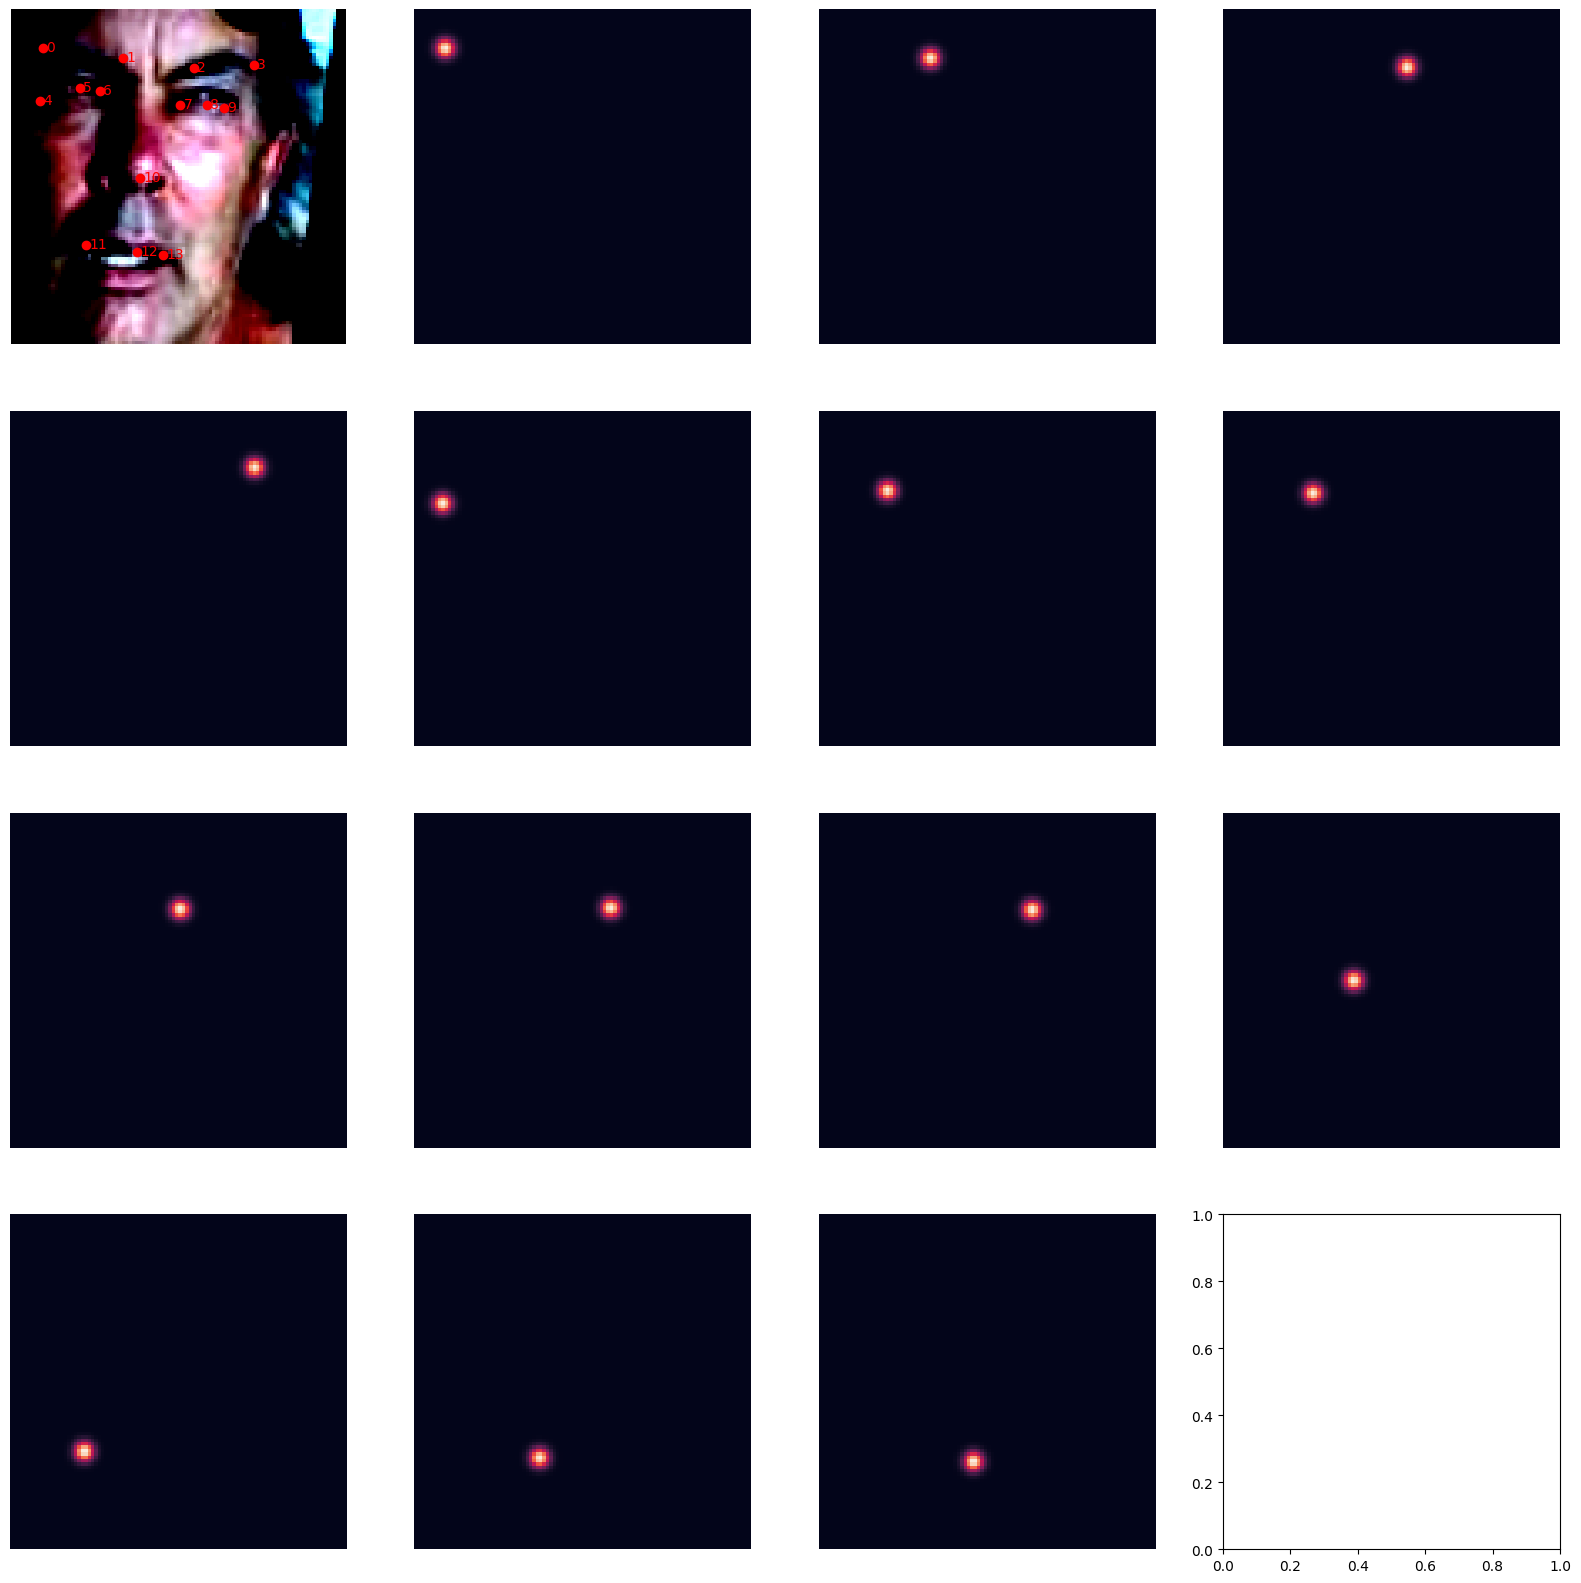

In [6]:
inputs, targets = next(iter(train_loader))
# visualize(inputs, heatmaps_to_coords(targets).flatten(1, -1))
visualize_heatmaps(inputs, targets, targets)
plt.show()

In [7]:
hparams = {
    "sigma": 2,
    "optimizer": "AdamW",
    "lr": 5e-4,
    "weight_decay": 5e-4,
    "batch_size": 32,
    "img_size": "100x100",
    "scheduler": "OneCycleLR",
    "max_lr": 5e-3,
    "grad_clip": 1.0,
    "epochs": 50,
}

In [9]:
model = UNet(ch_mul=32)
# ema_model = swa_utils.AveragedModel(model, avg_fn=lambda avg, new, n: 0.999 * avg + 0.001 * new)
optimizer = torch.optim.AdamW(model.parameters(), lr=hparams['lr'], weight_decay=hparams['weight_decay'])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=hparams['max_lr'],
    steps_per_epoch=len(train_loader),
    epochs=hparams['epochs'],
)
logger = SummaryWriter(log_dir='./logs/exp_model_heatmap4')
trainer = Trainer(
    model=model.to(device),
    criterion=weighted_mse_loss,
    optimizer=optimizer,
    scheduler=scheduler,
    logger=logger,
    device=device,
)
sum(p.numel() for p in model.parameters())

1939502

In [ ]:
val_losses, ema_val_losses = trainer.train(train_loader, val_loader, n_epochs=hparams['epochs'])
logger.add_hparams(hparams, {"val_loss": val_losses[-1]})
logger.close()

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
torch.save(
    {
        'epoch': hparams['epochs'],
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_losses[-1],
    },
    './checkpoints/pretrained_model_checkpoint_0.pt',
)

In [ ]:
swa_model = AveragedModel(model)
n_epochs = 10
trainer.scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_epochs * len(train_loader), eta_min=1e-8,
)
trainer.logger=SummaryWriter(log_dir='./logs/pretrained_model0')